# Multiclass Classification with the [Covertype](https://archive.ics.uci.edu/dataset/31/covertype) Dataset

1. Read the dataset documentation.
2. Explore the dataset.
3. Perform the train-test split
4. Decide how we will normalize the data.
5. Fit a logistic regression model on the training set.
6. Evaluate the model performance on the testing set.
7. Make a custom confusion matrix plot.

In [9]:
!pip install zca

In [10]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from zca import ZCA
from sklearn import datasets
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics

In [11]:
df, targets = datasets.fetch_covtype(return_X_y=True, as_frame=True)

In [12]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.044175,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.205483,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_0',
       'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3',
       'Soil_Type_0', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3',
       'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7',
       'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11',
       'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15',
       'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19',
       'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23',
       'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27',
       'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31',
       'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35',
       'Soil_Type_36', 'S

In [14]:
columns = ['Elevation', 'Aspect', 'Slope']
columns

['Elevation', 'Aspect', 'Slope']

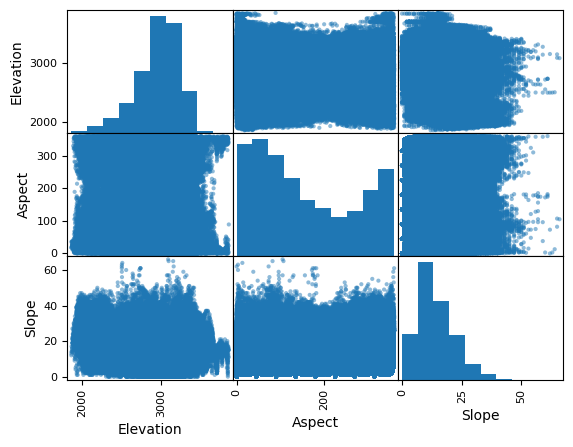

In [15]:
pd.plotting.scatter_matrix(df[columns]);

In [22]:
from sklearn.model_selection import train_test_split
Xtrn, Xtst, Ytrn, Ytst = train_test_split(df, targets, test_size=0.50, random_state=1415, stratify=targets)

In [23]:
Xtrn.shape, Xtst.shape, Ytrn.shape, Ytst.shape

((290506, 54), (290506, 54), (290506,), (290506,))

In [26]:
scaler = preprocessing.StandardScaler()
scaler.fit(Xtrn)
Xtrn_scaled = scaler.transform(Xtrn)
Xtrn_scaled = pd.DataFrame(Xtrn_scaled, columns=df.columns)

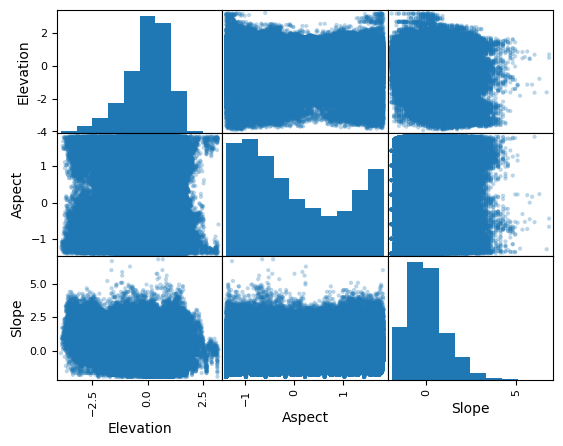

In [29]:
pd.plotting.scatter_matrix(Xtrn_scaled[columns], alpha=0.3);

In [31]:
logreg = linear_model.LogisticRegression()
logreg.fit(Xtrn_scaled, Ytrn)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [33]:
Ptrn = logreg.predict(Xtrn_scaled)

In [34]:
print(metrics.classification_report(Ytrn, Ptrn))

              precision    recall  f1-score   support

           1       0.71      0.70      0.71    105920
           2       0.75      0.80      0.77    141650
           3       0.67      0.81      0.74     17877
           4       0.61      0.39      0.48      1374
           5       0.21      0.01      0.01      4746
           6       0.49      0.24      0.32      8684
           7       0.73      0.57      0.64     10255

    accuracy                           0.72    290506
   macro avg       0.60      0.50      0.52    290506
weighted avg       0.71      0.72      0.71    290506



In [35]:
Xtst_scaled = scaler.transform(Xtst)
Xtst_scaled = pd.DataFrame(Xtst_scaled, columns=df.columns)
Xtst_scaled.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
count,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,...,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000,290506.000000
mean,-0.001479,-0.000741,0.000156,0.000596,0.000752,-0.004093,0.000875,-0.001684,-0.001953,-0.001259,...,-0.001472,-0.003580,0.000875,-0.002139,-0.003394,-0.002087,-0.005710,0.001645,-0.000677,-0.005203
std,0.998836,0.999261,1.001522,0.997328,1.003627,0.998065,1.004531,0.999293,1.002477,0.998036,...,0.996737,0.994887,1.001382,0.979779,0.970395,0.927041,0.873740,1.004822,0.997884,0.979284
min,-3.928544,-1.390721,-1.884803,-1.265613,-3.770381,-1.507817,-7.942339,-11.293437,-3.729433,-1.494630,...,-0.215365,-0.316224,-0.290047,-0.053269,-0.058000,-0.014844,-0.024126,-0.165534,-0.156188,-0.124981
25%,-0.537475,-0.872656,-0.682003,-0.758174,-0.677045,-0.801110,-0.529193,-0.522630,-0.616462,-0.722089,...,-0.215365,-0.316224,-0.290047,-0.053269,-0.058000,-0.014844,-0.024126,-0.165534,-0.156188,-0.124981
50%,0.130030,-0.256338,-0.147426,-0.241338,-0.281786,-0.229594,0.219610,0.134743,0.011364,-0.204547,...,-0.215365,-0.316224,-0.290047,-0.053269,-0.058000,-0.014844,-0.024126,-0.165534,-0.156188,-0.124981
75%,0.726144,0.931639,0.520796,0.566805,0.388437,0.619351,0.706332,0.690982,0.665350,0.429178,...,-0.215365,-0.316224,-0.290047,-0.053269,-0.058000,-0.014844,-0.024126,-0.165534,-0.156188,-0.124981
max,3.203409,1.824854,6.935726,5.265313,9.530962,3.052140,1.567455,1.550624,2.915060,3.916176,...,4.643282,3.162320,3.447717,18.772683,17.241252,67.365839,41.448407,6.041053,6.402560,8.001203


In [36]:
Ptst = logreg.predict(Xtst_scaled)
print(metrics.classification_report(Ytst, Ptst))

              precision    recall  f1-score   support

           1       0.71      0.70      0.70    105920
           2       0.75      0.80      0.77    141651
           3       0.67      0.82      0.74     17877
           4       0.61      0.38      0.47      1373
           5       0.22      0.01      0.01      4747
           6       0.50      0.25      0.33      8683
           7       0.73      0.57      0.64     10255

    accuracy                           0.72    290506
   macro avg       0.60      0.50      0.52    290506
weighted avg       0.71      0.72      0.71    290506



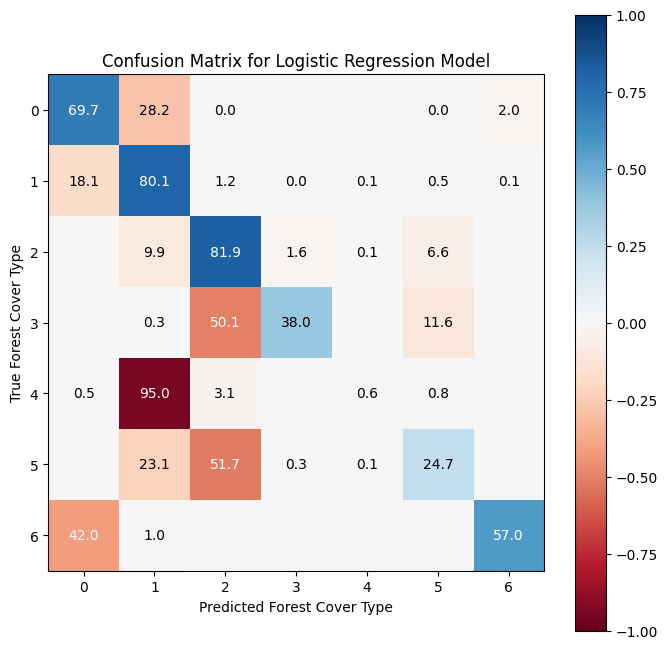

In [60]:
fig, ax = plt.subplots(figsize=(8, 8))
cm = metrics.confusion_matrix(Ytst, Ptst, normalize="true")
off_diag = ~np.eye(cm.shape[0], dtype=bool)
cm[off_diag] *= -1

im = ax.imshow(cm, cmap="RdBu", vmin=-1, vmax=1)
fig.colorbar(im)

ax.set_title("Confusion Matrix for Logistic Regression Model")
ax.set_xlabel("Predicted Forest Cover Type")
ax.set_ylabel("True Forest Cover Type")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = np.abs(cm[i, j])
        if val == 0:
            continue
        text = f"{val*100:.1f}"
        color = "k"
        if val >= cm.max() / 2:
            color = "w"
        ax.text(j, i, text, c=color, ha="center", va="center")

fig.show()